In [9]:
from metrics          import eval_model, compare_metric
from torch.utils.data import DataLoader, TensorDataset
from model            import GenerateModel
from training         import train_model
from gensim.models    import Word2Vec
from tqdm             import tqdm

import numpy             as np
import matplotlib.pyplot as plt
import torch
import os

# device     = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu'); print(f'Deivce: {device}')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'); print(f'Deivce: {device}')
model_path = os.path.join(os.getcwd(),'Model','model.tar')

Deivce: cuda


In [10]:
X_train = np.load('X_train.npy')
X_test  = np.load('X_test.npy')

Y_train = np.load('Y_train.npy')
Y_test  = np.load('Y_test.npy')

X_train = torch.from_numpy(X_train).long()
Y_train = torch.from_numpy(Y_train).type(torch.float32)
X_test  = torch.from_numpy(X_test) .long()
Y_test  = torch.from_numpy(Y_test) .type(torch.float32) 

train_loader = DataLoader(TensorDataset(X_train,Y_train), batch_size = 16,shuffle=False, pin_memory = True)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test) , batch_size = 64,shuffle=False, pin_memory = True)

In [11]:
model = GenerateModel(); model.to(device)
model.load_state_dict(torch.load(os.path.join(os.getcwd(),'Model','model.tar'),weights_only=True,map_location=device))

<All keys matched successfully>

In [ ]:
epochs = 4000

In [13]:
model.to(device=device)
loss_module = torch.nn.BCEWithLogitsLoss()
optimizer   = torch.optim.Adam(model.parameters(), lr = 0.0001, betas =  (0.9,0.99))

intermediate_hist = []
for epoch in tqdm(range(epochs)):
    hist, best_model, best_loss = train_model(model = model,
                        device      = device,
                        optimizer   = optimizer,
                        data_loader = train_loader,
                        loss_module = loss_module,
                        num_epochs  = 1)
    if epoch % 1 == 0:
        h = eval_model(model = model,device = device,label_space = 50,data_loader  = test_loader)
        intermediate_hist.append(h)

100%|██████████| 500/500 [14:00<00:00,  1.68s/it]


In [14]:
torch.save(model.state_dict(),f = os.path.join(os.getcwd(),'Model','model2.tar'))

In [19]:
intermediate_hist[0]['auc_micro'],intermediate_hist[-1]['auc_micro']

(0.9334093150078369, 0.9339014867387048)

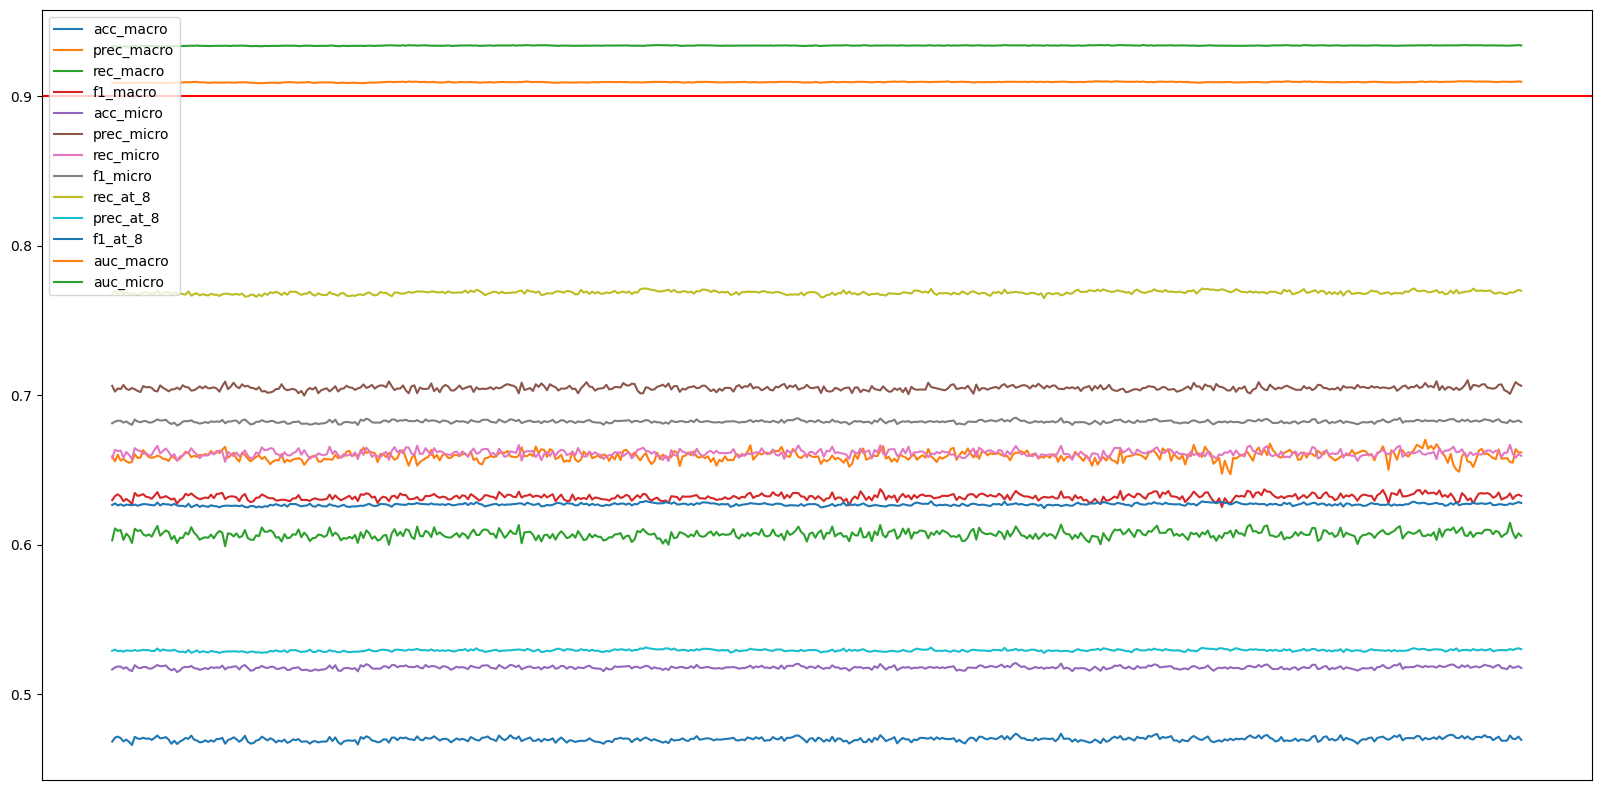

In [ ]:
# Visualize the eval over the different training size
plt.figure(figsize=(20,10))
plt.tick_params(
    axis   ='x',          
    which  ='both',      
    bottom = False,      
    top    = False,
    labelbottom = False)

for key in intermediate_hist[0].keys():
    # plt.plot([_ for _ in range(epochs//1)],[m[key] for m in intermediate_hist], label = key)
    plt.plot([m[key] for m in intermediate_hist], label = key)
plt.legend()
plt.axhline(y=0.9, color='r', linestyle='-')
plt.savefig('training3.png')

---

In [20]:
benchmark = {
    'auc_macro' : 0.884,
    'auc_micro' : 0.916,
    'f1_macro'  : 0.576,
    'f1_micro'  : 0.633
}

In [21]:
model.load_state_dict(torch.load(os.path.join(os.getcwd(),'Model','model2.tar'),weights_only=True,map_location=device))

<All keys matched successfully>

In [22]:
results = eval_model(
           model  = model,
           device = device,
           data_loader = test_loader,
           label_space = 50)

In [23]:
for k,v in benchmark.items():
    if k in results:
        print(compare_metric(benchmark,results,k))

auc_macro: 2.90% change (0.8840 → 0.9096)
auc_micro: 1.95% change (0.9160 → 0.9339)
f1_macro: 9.80% change (0.5760 → 0.6325)
f1_micro: 7.74% change (0.6330 → 0.6820)
